## The project analyzes sales data for the company EmporiUm, the goal is to evaluate business perfomance for the assigned territories and provide a marketing recomemendation. 

## ASSIGNED TERRITORIES 
## -Territory 1: Connecticut
## -Territory 2: New York

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
storesales = pd.read_csv("StoreSales.csv")
storesales.info()
storesales.head() #preview making sure files run

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [3]:
storedetails = pd.read_csv("StoreDetail.csv")
storedetails.info()
storedetails.head() #preview making sure files run

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [4]:
products = pd.read_csv("Products.csv")
products.info()
products.head() #preview making sure files run

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [5]:
productcategories = pd.read_csv("ProductCategories.csv")
productcategories.info()
productcategories.head() #preview making sure files run

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [6]:
customerlist = pd.read_csv("customer_list.csv")
customerlist.info()
customerlist.head() #preview making sure files run

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    object
dtypes: object(1)
memory usage: 4.2+ KB


,cust_id|date|time|name|email|phone|sms-opt-out
0,1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1,2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2,3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3,4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4,5|2023-11-18|14:22:10|Joey|howyoudoing@central...


# Core Marketing Analysis.

The marketing manager wants to know:

∗ Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?

∗ What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?

∗ How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

∗ Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?

∗ What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category? What might this tell you about the most popular products, and where could there be opportunity for growth?

∗ What is your recommendation for where to focus marketing attention in the next quarter?

## QUESTION 1:
## Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?


In [7]:
storedetails.head()#reviewing columns 

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [8]:
ny_ct_stores = storedetails[storedetails["State"].isin(["New York", "Connecticut"])] #Filtering ONLY the State of NY and CT 

In [9]:
ny_ct_stores.sort_values(["State", "Store Location"]) #Cleaning/organizing for neat output

,Store Location,State,Store ID,Territory Manager,Region,Region Director
18,Bridgeport,Connecticut,865,Ellen Lemon,East,Ana Jilani
19,Darien,Connecticut,866,Ellen Lemon,East,Ana Jilani
20,Hartford,Connecticut,867,Ellen Lemon,East,Ana Jilani
21,Litchfield County,Connecticut,868,Ellen Lemon,East,Ana Jilani
22,New Haven,Connecticut,869,Ellen Lemon,East,Ana Jilani
23,New London,Connecticut,870,Ellen Lemon,East,Ana Jilani
24,Old Saybrook,Connecticut,871,Ellen Lemon,East,Ana Jilani
25,Waterbury,Connecticut,872,Ellen Lemon,East,Ana Jilani
86,Albany,New York,840,See Ellefson,East,Ana Jilani
95,Brooklyn,New York,849,See Ellefson,East,Ana Jilani


In [10]:
ny_ct_stores.groupby("State")["Territory Manager"].unique() #Group by territory manager for cleaner output

State
Connecticut     [Ellen Lemon]
New York       [See Ellefson]
Name: Territory Manager, dtype: object

## QUESTION 1 OVERVIEW:
## Connecticut territory is managed by Ellen Lemon and stores are located in cities like Bridgeport, Darien and Hartford.
## New York territory is managed by See Ellefson and stores are located in cities like Albany, Brooklyn and Buffalo.
## Each store has its own unique ID that helps us identify the store within the territory.

## QUESTION 2: 
## What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?


In [11]:
storesales.head() #reviewing columns

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [12]:
sales_location = storesales.merge(storedetails, on ="Store ID") #Using merge to connect store sales to store location

In [13]:
ny_ct_sales = sales_location[
    sales_location["State"].isin(["New York", "Connecticut"])
].copy() #Filtering for my specific territories 

In [14]:
ny_ct_sales["Transaction Date"] = pd.to_datetime(ny_ct_sales["Transaction Date"]) #Filtering to define the time based analysis

In [15]:
ny_ct_sales["Month"] = ny_ct_sales["Transaction Date"].dt.to_period("M") #Grouping sales by the month

In [16]:
monthly_revenue = ny_ct_sales.groupby(
    ["State", "Month"]
)["Sale Amount"].sum() #Calculating monthly revenue

In [17]:
monthly_revenue # Reviewing data broken down by state and monthly sales total

State        Month  
Connecticut  2022-01     29958.25
             2022-02     25563.98
             2022-03     33995.57
             2022-04     31587.12
             2022-05     37953.48
                          ...    
New York     2025-08    133776.60
             2025-09    119597.00
             2025-10    185241.67
             2025-11    126941.06
             2025-12    128272.56
Name: Sale Amount, Length: 96, dtype: float64

In [18]:
monthly_revenue = monthly_revenue.reset_index()
monthly_revenue #Data clean up using reset index shows NY vs CT columns


,State,Month,Sale Amount
0,Connecticut,2022-01,29958.25
1,Connecticut,2022-02,25563.98
2,Connecticut,2022-03,33995.57
3,Connecticut,2022-04,31587.12
4,Connecticut,2022-05,37953.48
...,...,...,...
91,New York,2025-08,133776.60
92,New York,2025-09,119597.00
93,New York,2025-10,185241.67
94,New York,2025-11,126941.06


In [19]:
pivot_table = monthly_revenue.pivot(
    index="Month",
    columns="State",
    values="Sale Amount"
) #Table to create chart to show Month State Sale Amount

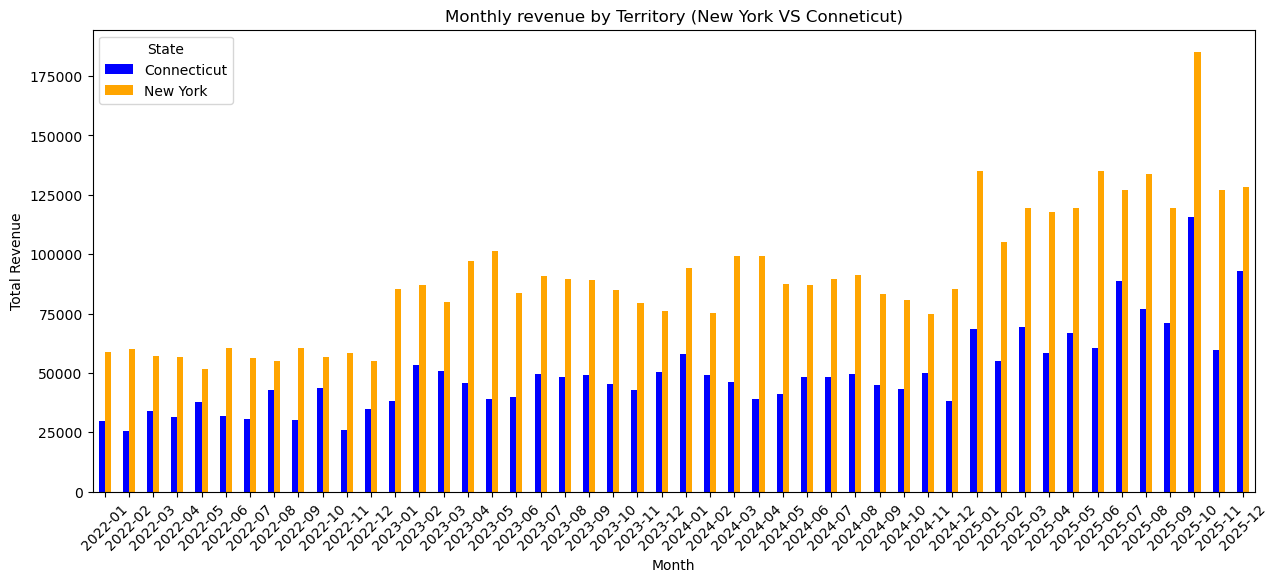

In [20]:
pivot_table.plot(kind="bar", figsize=(15,6),color =["Blue","Orange"])  #Creating chart Type/Size/Color
plt.title("Monthly revenue by Territory (New York VS Conneticut)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()
sns.set_style("whitegrid")

## QUESTION 2 OVERVIEW:
## The bar chart above compares the monthly revenue between New York and Conneticut. 
## The blue bar represents Conneticut while the Green represents New York. 
## Each bar reflects the month and amount of revenue from January 2022 - December 2025.
## The bar chart helps us identify trends and visualize which territory is performing better and the difference between revenue. 


## QUESTION 3: 
## How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?


In [21]:
store_performance = ny_ct_sales.groupby(
    ["State", "Store ID"]
)["Sale Amount"].sum().reset_index() #Calculating sales per store within each state

store_performance["Rank"] = store_performance.groupby("State")["Sale Amount"]\
    .rank(method="dense", ascending=False) #Created the Ranking between each state


In [22]:
store_performance = store_performance.sort_values(
    ["State", "Rank"]
) #Sorting for organization

In [23]:
top_stores = store_performance[store_performance["Rank"] <= 5]
# Identifying top stores showing top 5

In [24]:
top_stores

,State,Store ID,Sale Amount,Rank
5,Connecticut,870,331116.76,1.0
0,Connecticut,865,322100.07,2.0
2,Connecticut,867,309592.06,3.0
7,Connecticut,872,295651.17,4.0
4,Connecticut,869,286779.43,5.0
18,New York,850,621565.02,1.0
15,New York,847,607148.21,2.0
14,New York,846,334175.88,3.0
9,New York,841,314979.99,4.0
10,New York,842,313971.65,5.0


In [25]:
top_stores = top_stores.sort_values(["State", "Rank"]) #Sorting Data by state Rank

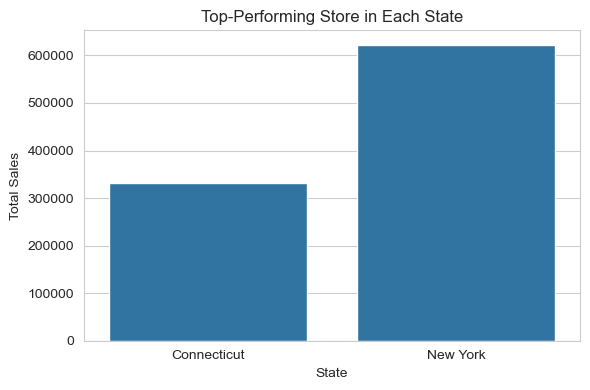

In [26]:

top_1 = store_performance[store_performance["Rank"] == 1]

plt.figure(figsize=(6,4))

sns.barplot(
    data=top_1,
    x="State",
    y="Sale Amount"
)

plt.title("Top-Performing Store in Each State")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()
sns.set_style("whitegrid")

## QUESTION 3 OVERVIEW:

## I ranked the sales performanced by first aggregating the total sales for each store within each territory, then I used the ranking method to order the store by highest to lowest sales amount and showed the top 5 stores in each state. 

## My top performing store in Connecticut is the New London location (Store ID 870) with a total sales amount of approximately $331,116

## For New York my top performing store is the New York location (Store ID 850) with a significantly higher sales amount at approximately $621,565. 

## While both stores provide a strong contribution to their assigned territories, 
## the New York location stands out as the highest performing store across my assigned territories with around 53% more sales. 

## QUESTION 4: 
## Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?


In [27]:
%who #using who to verify all varibles in code memory

No variables match your requested type.


In [28]:
print(ny_ct_sales.columns) #reviewing columns

Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount',
       'Store Location', 'State', 'Territory Manager', 'Region',
       'Region Director', 'Month'],
      dtype='object')


In [29]:

print(customerlist.columns)
print(ny_ct_sales.columns) #reviewing columns for customer ID info
#getting an error needing to seperate columns in csv file 


Index(['cust_id|date|time|name|email|phone|sms-opt-out '], dtype='object')
Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount',
       'Store Location', 'State', 'Territory Manager', 'Region',
       'Region Director', 'Month'],
      dtype='object')


In [30]:
customerlist = pd.read_csv("customer_list.csv", sep="|") #using sep to divide columns in csv

In [31]:
print(customerlist.columns)

Index(['cust_id', 'date', 'time', 'name', 'email', 'phone', 'sms-opt-out '], dtype='object')


In [32]:
merged_data = ny_ct_sales.merge(
    customerlist,
    left_on="RewardsID",
    right_on="cust_id",
    how="inner"
)
 #merging matching coloumns Reward ID and customer ID



In [33]:
customer_performance = merged_data.groupby(
    ["State", "cust_id"]
)["Sale Amount"].sum().reset_index() #grouping merged data aby state/customer id and getting sum of sales amount


In [34]:
customer_performance["Rank"] = customer_performance.groupby("State")["Sale Amount"]\
    .rank(method="dense", ascending=False) #Ranking customer data in each state


In [35]:
top_customers = customer_performance[customer_performance["Rank"] <= 5] #showing top 5 customers in each territory

In [36]:
top_customers

,State,cust_id,Sale Amount,Rank
17,Connecticut,18,4388.87,1.0
20,Connecticut,21,3676.21,2.0
98,Connecticut,104,2886.72,5.0
311,Connecticut,322,3569.60,3.0
351,Connecticut,365,3009.29,4.0
628,New York,129,3918.72,2.0
687,New York,188,3805.61,3.0
698,New York,199,3441.19,5.0
799,New York,300,6039.32,1.0
982,New York,483,3504.20,4.0


In [37]:
top_customers = top_customers.merge(
    customerlist[["cust_id"]],
    on="cust_id",
    how="left"
) #adding customer name column for results

In [38]:
top_customers #not in order need to organize data

,State,cust_id,Sale Amount,Rank
0,Connecticut,18,4388.87,1.0
1,Connecticut,21,3676.21,2.0
2,Connecticut,104,2886.72,5.0
3,Connecticut,322,3569.60,3.0
4,Connecticut,365,3009.29,4.0
5,New York,129,3918.72,2.0
6,New York,188,3805.61,3.0
7,New York,199,3441.19,5.0
8,New York,300,6039.32,1.0
9,New York,483,3504.20,4.0


In [39]:
top_customers = top_customers.sort_values(
    ["State", "Rank"] #sorted by state & by ranking
)
top_customers 

,State,cust_id,Sale Amount,Rank
0,Connecticut,18,4388.87,1.0
1,Connecticut,21,3676.21,2.0
3,Connecticut,322,3569.60,3.0
4,Connecticut,365,3009.29,4.0
2,Connecticut,104,2886.72,5.0
8,New York,300,6039.32,1.0
5,New York,129,3918.72,2.0
6,New York,188,3805.61,3.0
9,New York,483,3504.20,4.0
7,New York,199,3441.19,5.0


## QUESTION 4 OVERVIEW: 

## The sales data was merged using Reward ID and the Cust_Id  to identify each individual. Total sales were then aggresgated for each and ranked in descending order.
## The top 5 customers were based on total spending and the data also shows who was the highest-value customer that contributed to most of the revenue.


## QUESTION 5: What is the number of transactions per month by product category in each assigned territory?
## What is total sales revenue per month by category? What might this tell you about the most popular products, and where could there be opportunity for growth?


In [40]:
ny_ct_sales = ny_ct_sales.merge(
    products[["Prod Num", "CategoryID"]],
    on="Prod Num",
    how="left") #Merge/Adding the category ID to sales

In [41]:
ny_ct_sales = ny_ct_sales.merge(
    productcategories[["CategoryID", "Category"]],
    on="CategoryID",
    how="left"
) #Merge/adding category name


In [53]:

summary = ny_ct_sales.groupby(
    ["State", "Month", "Category"]
).agg(
    Transaction_Count=("Sale Amount", "count"),
    Total_Revenue=("Sale Amount", "sum")
).reset_index()

summary = summary.sort_values(["State", "Month", "Category"])

summary.head()


,State,Month,Category,Transaction_Count,Total_Revenue
0,Connecticut,2022-01,Apparel and Merchandise,336,9786.00
1,Connecticut,2022-01,Art Supplies,319,7184.32
2,Connecticut,2022-01,Books (General),76,1958.40
3,Connecticut,2022-01,Stationery and Supplies,396,3679.39
4,Connecticut,2022-01,Technology & Accessories,315,153020.42


In [54]:
summary.tail()

,State,Month,Category,Transaction_Count,Total_Revenue
571,New York,2025-12,Art Supplies,1397,39183.98
572,New York,2025-12,Books (General),304,8563.72
573,New York,2025-12,Stationery and Supplies,2101,22692.67
574,New York,2025-12,Technology & Accessories,1596,684607.21
575,New York,2025-12,Textbooks,1067,177840.85


In [55]:
summary.groupby("State").head(5)

,State,Month,Category,Transaction_Count,Total_Revenue
0,Connecticut,2022-01,Apparel and Merchandise,336,9786.00
1,Connecticut,2022-01,Art Supplies,319,7184.32
2,Connecticut,2022-01,Books (General),76,1958.40
3,Connecticut,2022-01,Stationery and Supplies,396,3679.39
4,Connecticut,2022-01,Technology & Accessories,315,153020.42
288,New York,2022-01,Apparel and Merchandise,528,17633.20
289,New York,2022-01,Art Supplies,561,12440.89
290,New York,2022-01,Books (General),96,3107.88
291,New York,2022-01,Stationery and Supplies,814,8260.67
292,New York,2022-01,Technology & Accessories,511,279678.00


In [56]:

summary_display = summary.sort_values(["State", "Month", "Category"])

summary_display.groupby("State").head(10)


,State,Month,Category,Transaction_Count,Total_Revenue
0,Connecticut,2022-01,Apparel and Merchandise,336,9786.00
1,Connecticut,2022-01,Art Supplies,319,7184.32
2,Connecticut,2022-01,Books (General),76,1958.40
3,Connecticut,2022-01,Stationery and Supplies,396,3679.39
4,Connecticut,2022-01,Technology & Accessories,315,153020.42
5,Connecticut,2022-01,Textbooks,341,59375.03
6,Connecticut,2022-02,Apparel and Merchandise,352,12032.80
7,Connecticut,2022-02,Art Supplies,264,8048.15
8,Connecticut,2022-02,Books (General),68,1756.40
9,Connecticut,2022-02,Stationery and Supplies,396,3699.63


In [58]:

for state in summary["State"].unique():
    print(f"\n===== {state} =====")
    display(summary[summary["State"] == state].head(10))



===== Connecticut =====


,State,Month,Category,Transaction_Count,Total_Revenue
0,Connecticut,2022-01,Apparel and Merchandise,336,9786.00
1,Connecticut,2022-01,Art Supplies,319,7184.32
2,Connecticut,2022-01,Books (General),76,1958.40
3,Connecticut,2022-01,Stationery and Supplies,396,3679.39
4,Connecticut,2022-01,Technology & Accessories,315,153020.42
5,Connecticut,2022-01,Textbooks,341,59375.03
6,Connecticut,2022-02,Apparel and Merchandise,352,12032.80
7,Connecticut,2022-02,Art Supplies,264,8048.15
8,Connecticut,2022-02,Books (General),68,1756.40
9,Connecticut,2022-02,Stationery and Supplies,396,3699.63



===== New York =====


,State,Month,Category,Transaction_Count,Total_Revenue
288,New York,2022-01,Apparel and Merchandise,528,17633.20
289,New York,2022-01,Art Supplies,561,12440.89
290,New York,2022-01,Books (General),96,3107.88
291,New York,2022-01,Stationery and Supplies,814,8260.67
292,New York,2022-01,Technology & Accessories,511,279678.00
293,New York,2022-01,Textbooks,858,152002.95
294,New York,2022-02,Apparel and Merchandise,560,16800.32
295,New York,2022-02,Art Supplies,682,22689.15
296,New York,2022-02,Books (General),120,2927.80
297,New York,2022-02,Stationery and Supplies,671,6723.09


In [60]:
summary.groupby("State").head(10)

,State,Month,Category,Transaction_Count,Total_Revenue
0,Connecticut,2022-01,Apparel and Merchandise,336,9786.00
1,Connecticut,2022-01,Art Supplies,319,7184.32
2,Connecticut,2022-01,Books (General),76,1958.40
3,Connecticut,2022-01,Stationery and Supplies,396,3679.39
4,Connecticut,2022-01,Technology & Accessories,315,153020.42
5,Connecticut,2022-01,Textbooks,341,59375.03
6,Connecticut,2022-02,Apparel and Merchandise,352,12032.80
7,Connecticut,2022-02,Art Supplies,264,8048.15
8,Connecticut,2022-02,Books (General),68,1756.40
9,Connecticut,2022-02,Stationery and Supplies,396,3699.63
